# 6CS012 - Worksheet 4: FCN for Devnagari Digit Classification


## Task 1: Data Preparation

Loading training data…
Loading test data…

Training set : (900, 784)  Labels: (900, 10)
Test set     : (900, 784)   Labels: (900, 10)


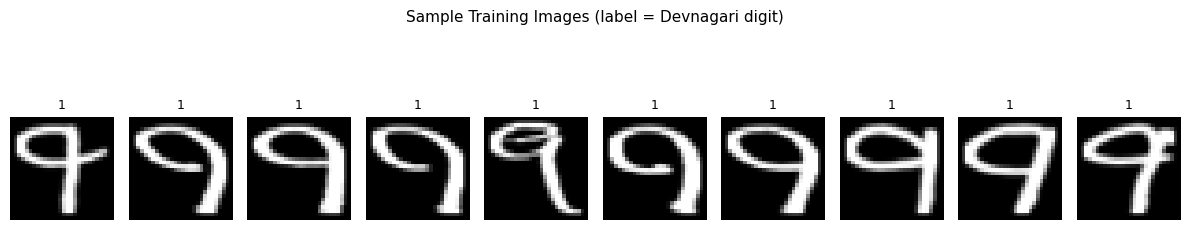

In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image

train_dir = '/content/drive/MyDrive/content/aayushma/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Test'
test_dir  = '/content/drive/MyDrive/content/aayushma/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Test'

IMG_HEIGHT = 28
IMG_WIDTH  = 28
NUM_CLASSES = 10

def load_images_from_folder(folder):
    """Load all images from a folder structured as folder/class_name/image.png"""
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))
    class_map   = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert('L')
                img = img.resize((IMG_WIDTH, IMG_HEIGHT))
                img = np.array(img) / 255.0
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f'Skipping {img_path}: {e}')

    return np.array(images), np.array(labels)

print('Loading training data…')
x_train_raw, y_train_raw = load_images_from_folder(train_dir)

print('Loading test data…')
x_test_raw, y_test_raw = load_images_from_folder(test_dir)
x_train = x_train_raw.reshape(-1, IMG_HEIGHT * IMG_WIDTH)
x_test  = x_test_raw.reshape(-1, IMG_HEIGHT * IMG_WIDTH)

y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

print(f'\nTraining set : {x_train.shape}  Labels: {y_train.shape}')
print(f'Test set     : {x_test.shape}   Labels: {y_test.shape}')

plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train_raw[i], cmap='gray')
    plt.title(str(np.argmax(y_train[i])), fontsize=9)
    plt.axis('off')
plt.suptitle('Sample Training Images (label = Devnagari digit)', fontsize=11)
plt.tight_layout()
plt.show()

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Task 2: Build the FCN Model

In [3]:
model = keras.Sequential(
    [
        keras.layers.Input(shape=(IMG_HEIGHT * IMG_WIDTH,)),

        keras.layers.Dense(64,  activation='sigmoid'),

        keras.layers.Dense(128, activation='sigmoid'),

        keras.layers.Dense(256, activation='sigmoid'),

        keras.layers.Dense(NUM_CLASSES, activation='softmax'),
    ],
    name='devnagari_fcn'
)

model.summary()

Model: "devnagari_fcn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

## Task 3: Compile the Model

In [4]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Model compiled successfully.')

Model compiled successfully.


## Task 4: Train the Model

Epoch 1/20
1/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.0000e+00 - loss: 2.2417
Epoch 1: val_loss improved from None to 2.51782, saving model to best_devnagari_model.keras

Epoch 1: finished saving model to best_devnagari_model.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - accuracy: 0.3931 - loss: 1.6879 - val_accuracy: 0.0000e+00 - val_loss: 2.5178
Epoch 2/20
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4453 - loss: 1.1935
Epoch 2: val_loss improved from 2.51782 to 1.90239, saving model to best_devnagari_model.keras

Epoch 2: finished saving model to best_devnagari_model.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5486 - loss: 1.0932 - val_accuracy: 0.0000e+00 - val_loss: 1.9024
Epoch 3/20
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6484 - loss: 1.0414
Epoch 3: val_loss improved from 1.90239 to 1.54258, saving model to best_devnagari_model.keras

Epoch 3: finished saving model to best_devnagari_model.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - acc

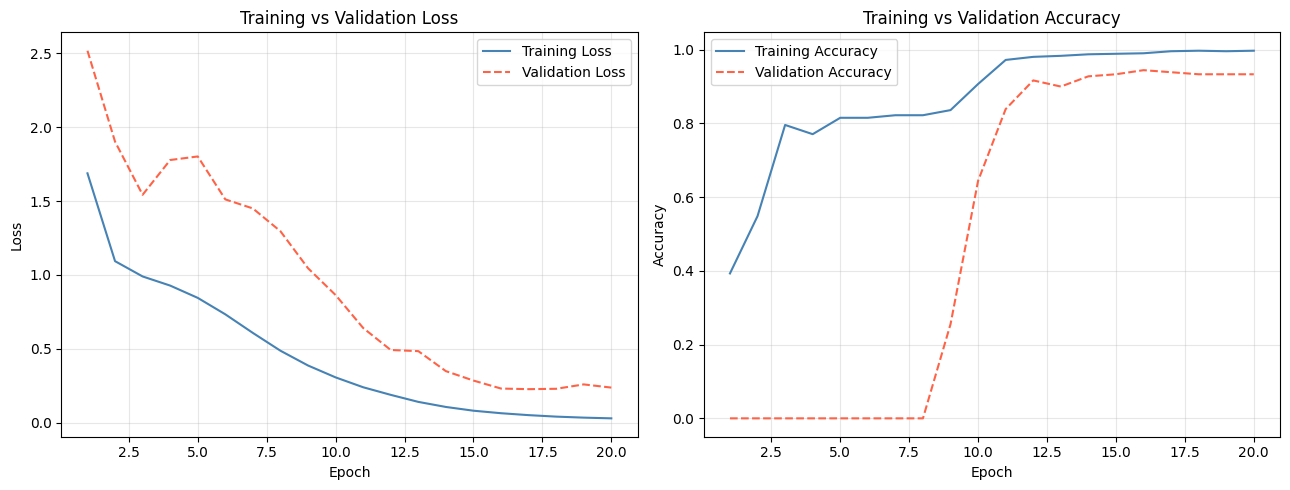

Training curves saved to training_curves.png


In [5]:
BATCH_SIZE = 128
EPOCHS     = 20

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath='best_devnagari_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
]

history = model.fit(
    x_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']
epochs_ran = range(1, len(train_loss) + 1)

plt.figure(figsize=(13, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_ran, train_loss, label='Training Loss',   color='steelblue')
plt.plot(epochs_ran, val_loss,   label='Validation Loss', color='tomato',  linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_ran, train_acc, label='Training Accuracy',   color='steelblue')
plt.plot(epochs_ran, val_acc,   label='Validation Accuracy', color='tomato',  linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print('Training curves saved to training_curves.png')

## Task 5: Evaluate the Model

In [6]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f'\n━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  Test Loss     : {test_loss:.4f}')
print(f'  Test Accuracy : {test_acc * 100:.2f}%')
print(f'━━━━━━━━━━━━━━━━━━━━━━━━━━━')

29/29 - 0s - 3ms/step - accuracy: 0.9856 - loss: 0.0799

━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Test Loss     : 0.0799
  Test Accuracy : 98.56%
━━━━━━━━━━━━━━━━━━━━━━━━━━━


## Task 6: Save and Load the Model

In [7]:
model.save('devnagari_fcn_model.h5')
print('Model saved to devnagari_fcn_model.h5')

loaded_model = tf.keras.models.load_model('devnagari_fcn_model.h5')
print('Model loaded successfully.')
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=0)
print(f'\nLoaded model — Test Loss: {loaded_loss:.4f} | Test Accuracy: {loaded_acc * 100:.2f}%')

Model saved to devnagari_fcn_model.h5
Model loaded successfully.

Loaded model — Test Loss: 0.0799 | Test Accuracy: 98.56%


## Task 7: Predictions

Predicted label for first test image : 1
True label for first test image      : 1


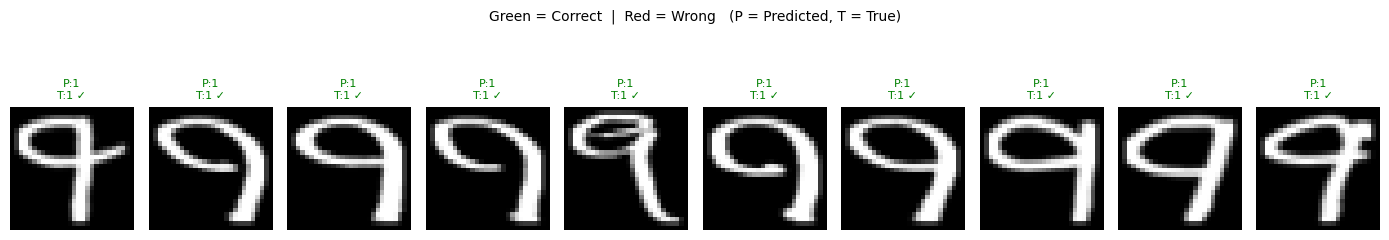


Overall — Correct: 887 / 900  |  Wrong: 13


In [8]:
predictions = loaded_model.predict(x_test, verbose=0)

predicted_labels = np.argmax(predictions, axis=1)
true_labels      = np.argmax(y_test,      axis=1)

print(f'Predicted label for first test image : {predicted_labels[0]}')
print(f'True label for first test image      : {true_labels[0]}')

plt.figure(figsize=(14, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_test_raw[i], cmap='gray')
    color  = 'green' if predicted_labels[i] == true_labels[i] else 'red'
    status = '✓' if predicted_labels[i] == true_labels[i] else '✗'
    plt.title(f'P:{predicted_labels[i]}\nT:{true_labels[i]} {status}',
              fontsize=8, color=color)
    plt.axis('off')
plt.suptitle('Green = Correct  |  Red = Wrong   (P = Predicted, T = True)', fontsize=10)
plt.tight_layout()
plt.show()

correct   = np.sum(predicted_labels == true_labels)
incorrect = len(true_labels) - correct
print(f'\nOverall — Correct: {correct} / {len(true_labels)}  |  Wrong: {incorrect}')